In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.model_selection import train_test_split

In [6]:
df_wine = pd.read_csv('data/wine/wine.data')

In [7]:
df_wine.head()

,Class labels,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [8]:
X,y = df_wine.iloc[:,1:].values, df_wine.iloc[:,0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [9]:
feat_labels = df_wine.columns[1:]
forest = RandomForestClassifier(n_estimators=100, random_state=1)
forest.fit(X_train, y_train)
importances = forest.feature_importances_

In [10]:
indices = np.argsort(importances)[::-1]

In [11]:
for f in range(X.shape[1]):
    print(f"{f + 1:2d}) {feat_labels[indices[f]]:<20} {importances[indices[f]]:.6f}")

 1) Color intensity      0.164909
 2) Flavanoids           0.164451
 3) Proline              0.158675
 4) OD280/OD315 of diluted wines 0.154081
 5) Alcohol              0.115701
 6) Hue                  0.070989
 7) Total phenols        0.053835
 8) Proanthocyanins      0.028817
 9) Alcalinity of ash    0.028478
10) Malic acid           0.024253
11) Magnesium            0.015646
12) Nonflavanoid phenols 0.010544
13) Ash                  0.009623


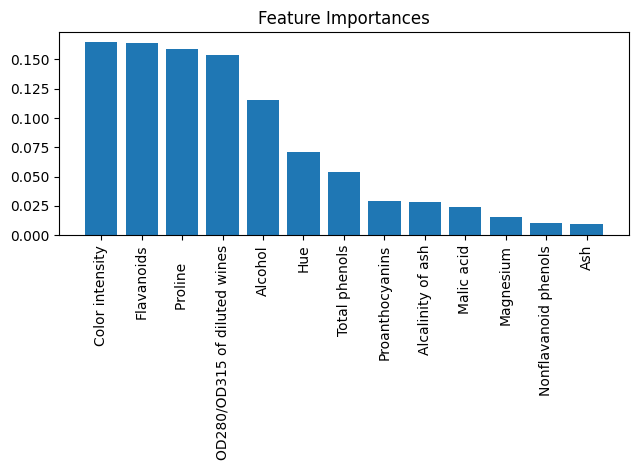

In [12]:
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), feat_labels[indices], rotation=90)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.feature_selection import SelectFromModel
sfm = SelectFromModel(forest, threshold=0.15, prefit=True)
X_selected = sfm.transform(X_train)
print(f'Number of features that meet this threshold: {X_selected.shape[1]}')

Number of features that meet this threshold: 4


In [15]:
for f in range(X_selected.shape[1]):
    print(f"{f + 1:2d}) {feat_labels[indices[f]]:<20} {importances[indices[f]]:.6f}")

 1) Color intensity      0.164909
 2) Flavanoids           0.164451
 3) Proline              0.158675
 4) OD280/OD315 of diluted wines 0.154081
